In [1]:
import torch
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

12.4
True
1


In [2]:
import sys
import os
import pickle
import logging
logging.getLogger('matplotlib.font_manager').disabled = True

# Add the src directory to sys.path

src_path = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.append(src_path)

import src

from src.IndependentSteps import Pycromanager2NativeDataType, FFF2NativeDataType, Make_Output_Dir_JF, Make_Analysis_Dir_JF, \
                                    ConsolidateImageShapes, TrimZSlices, AutomaticSpotDetection_JF

from src.SequentialSteps import CellSegmentationStepClass_JF, BIGFISH_SpotDetection, SimpleCellposeSegmentaion, rescale_images, remove_background, \
                                exposure_correction, TrackPy_SpotDetection

from src.FinalizationSteps import BuildPDFReport, SaveSpotDetectionResults, SaveMasksToAnalysis, SendAnalysisToNAS, TrackPyAnlaysis

from src import Experiment, Settings, ScopeClass, Pipeline, DataContainer

print('Will it blend?')

Will it blend?


In [3]:
# raw_data_dir = r'C:\Users\Jack\Desktop\H128_Tiles_100ms_5mW_Blue_15x15_10z_05step_2'
raw_data_dir = r"Users\Jack\JackRealImages_nzstack-13_zstep-0.5_nTimes-1_tInterval-0_7"
# raw_data_dir = r"RNA_diffusion_data\03052024_H128_IntronDiffusion\H128FastVids_5ms_0ND_green_40mw_5"
# Build Setting Classes
pipelineSettings = Settings(user_select_number_of_images_to_run=3, download_data_from_NAS=1)
pipelineSettings.verbose = True
pipelineSettings.bigfish_alpha = 0.97
pipelineSettings.bigfish_min_threshold = 10
pipelineSettings.cellpose_diameter = [180, 100]
pipelineSettings.cellpose_model_type = ['cyto3', 'nuclei']
pipelineSettings.cellpose_flow_threshold = [0.6, 1]
pipelineSettings.display_plots = True
pipelineSettings.MINIMAL_NUMBER_OF_Z_SLICES_TO_CONSIDER_A_3D_IMAGE = 5
pipelineSettings.load_in_mask = True
pipelineSettings.luis_trick = False

pipelineSettings.spot_yx_px = 11
pipelineSettings.spot_z_px = 3




terminatorScope = ScopeClass()
terminatorScope.voxel_size_yx = 130
terminatorScope.spot_yx = 260
terminatorScope.spot_z = 500


experiment = Experiment()
experiment.initial_data_location = raw_data_dir
experiment.cytoChannel = [0]
experiment.nucChannel = [2]
experiment.FISHChannel = [1, 2]
experiment.voxel_size_z = 500

pipelineData = DataContainer()

# Create Pipeline 
prePipelineSteps = [Pycromanager2NativeDataType(), Make_Output_Dir_JF(), Make_Analysis_Dir_JF()] #remove_background(), exposure_correction()]
pipelineSteps = [SimpleCellposeSegmentaion(), TrackPy_SpotDetection()] # BIGFISh_SpotDetection()]
postPipelineSteps = [TrackPyAnlaysis(), BuildPDFReport(), SaveSpotDetectionResults(), SaveMasksToAnalysis()]
pipeline = Pipeline(pipelineSettings, terminatorScope, experiment, pipelineData, prePipelineSteps, postPipelineSteps, pipelineSteps)


The following parameters are required in the run the pipeline
['voxel_size_z', 'output_location', 'image_name', 'df_spotresults', 'initial_data_location', 'timestep_s', 'cytoChannel', 'spot_z_px', 'FISHChannel', 'id', 'df_clusterresults', 'map_id_imgprops', 'spot_yx_px', 'df_cellresults', 'analysis_location', 'list_images', 'voxel_size_yx', 'nucChannel', 'kwargs', 'image']


INFO:SMB.SMBConnection:Authentication with remote machine "MUNSKY-NAS.ENGR.COLOSTATE.EDU" for user "formanj" will be using NTLM v2 authentication (with extended security)
INFO:SMB.SMBConnection:Now switching over to SMB2 protocol communication
DEBUG:SMB.SMBConnection:Received SMB2 message "SMB2_COM_NEGOTIATE" (command:0x0000 flags:0x0001)
INFO:SMB.SMBConnection:SMB2 dialect negotiation successful


Pycromanager2NativeDataType


DEBUG:SMB.SMBConnection:Received SMB2 message "SMB2_COM_SESSION_SETUP" (command:0x0001 flags:0x0001)
INFO:SMB.SMBConnection:Performing NTLMv2 authentication (on SMB2) with server challenge "b'6445b66eb1899467'"
INFO:SMB.SMBConnection:Performing NTLMv2 authentication (on SMB2) with server challenge "b'6445b66eb1899467'"
DEBUG:SMB.SMBConnection:NT challenge response is "b'e13e01fc70925e8f35d9ac76c2e43962010100000000000000000000000000007ced891fe2023f38000000000200100045004e00470052005f0044004f004d00010014004d0055004e0053004b0059002d004e00410053000400240065006e00670072002e0063006f006c006f00730074006100740065002e0065006400750003003a006d0075006e0073006b0079002d006e00610073002e0065006e00670072002e0063006f006c006f00730074006100740065002e00650064007500070008005af98f4cbf29db0100000000'" (206 bytes)
DEBUG:SMB.SMBConnection:LM challenge response is "b'd6bcb4484ea12f4552dfc6be9c74ab147ced891fe2023f38'" (24 bytes)
INFO:SMB.SMBConnection:Server supports SMB signing
INFO:SMB.SMBConnection:SMB signing 

Connection established


DEBUG:SMB.SMBConnection:Received SMB2 message "SMB2_COM_CREATE" (command:0x0005 flags:0x0001)
DEBUG:SMB.SMBConnection:Received SMB2 message "SMB2_COM_QUERY_INFO" (command:0x0010 flags:0x0001)
DEBUG:SMB.SMBConnection:Received SMB2 message "SMB2_COM_READ" (command:0x0008 flags:0x0001)
DEBUG:SMB.SMBConnection:Received SMB2 message "SMB2_COM_CLOSE" (command:0x0006 flags:0x0001)
DEBUG:SMB.SMBConnection:Received SMB2 message "SMB2_COM_CREATE" (command:0x0005 flags:0x0001)
DEBUG:SMB.SMBConnection:Received SMB2 message "SMB2_COM_QUERY_INFO" (command:0x0010 flags:0x0001)


File Downloaded : NDTiff.index
File Downloaded : JackRealImages_nzstack-13_zstep-0.5_nTimes-1_tInterval-0_NDTiffStack.tif


DEBUG:SMB.SMBConnection:Received SMB2 message "SMB2_COM_READ" (command:0x0008 flags:0x0001)
DEBUG:SMB.SMBConnection:Received SMB2 message "SMB2_COM_READ" (command:0x0008 flags:0x0001)
DEBUG:SMB.SMBConnection:Received SMB2 message "SMB2_COM_READ" (command:0x0008 flags:0x0001)
DEBUG:SMB.SMBConnection:Received SMB2 message "SMB2_COM_READ" (command:0x0008 flags:0x0001)
DEBUG:SMB.SMBConnection:Received SMB2 message "SMB2_COM_READ" (command:0x0008 flags:0x0001)
DEBUG:SMB.SMBConnection:Received SMB2 message "SMB2_COM_READ" (command:0x0008 flags:0x0001)
DEBUG:SMB.SMBConnection:Received SMB2 message "SMB2_COM_READ" (command:0x0008 flags:0x0001)
DEBUG:SMB.SMBConnection:Received SMB2 message "SMB2_COM_READ" (command:0x0008 flags:0x0001)
DEBUG:SMB.SMBConnection:Received SMB2 message "SMB2_COM_READ" (command:0x0008 flags:0x0001)
DEBUG:SMB.SMBConnection:Received SMB2 message "SMB2_COM_READ" (command:0x0008 flags:0x0001)
DEBUG:SMB.SMBConnection:Received SMB2 message "SMB2_COM_READ" (command:0x0008 fl

Files downloaded to: c:\Users\Jack\Documents\GitHub\FISH_Processing\publications\GRFP_JackForman_2024\temp_JackRealImages_nzstack-13_zstep-0.5_nTimes-1_tInterval-0_7
Image shape:  (13, 512, 512, 3) 

Number of images:  1 

Local directory with images:  c:\Users\Jack\Documents\GitHub\FISH_Processing\publications\GRFP_JackForman_2024\temp_JackRealImages_nzstack-13_zstep-0.5_nTimes-1_tInterval-0_7 

Dataset opened                
Number of z slices:  13 
 Number of color channels:  3 
Number of FOV:  1 
 Number of TimePoints 1 
 
 

Pycromanager2NativeDataType did not return a value
Make_Output_Dir_JF
Make_Analysis_Dir_JF

 ###################### 
        IMAGE : 0
 ###################### 
    Image Name :   JackRealImages_nzstack-13_zstep-0_tp_0_fov_0.tif


INFO:cellpose.core:>>>> using GPU (CUDA)
INFO:cellpose.models:>> nuclei << model set to be used
INFO:cellpose.models:>>>> loading model C:\Users\Jack\.cellpose\models\nucleitorch_0
INFO:cellpose.models:>>>> model diam_mean =  17.000 (ROIs rescaled to this size during training)
INFO:cellpose.models:channels set to [[0, 2]]
INFO:cellpose.models:~~~ FINDING MASKS ~~~
DEBUG:numba.core.byteflow:bytecode dump:
>          0	NOP(arg=None, lineno=106)
           2	RESUME(arg=0, lineno=106)
           4	LOAD_GLOBAL(arg=1, lineno=120)
          14	LOAD_ATTR(arg=2, lineno=120)
          34	LOAD_GLOBAL(arg=5, lineno=120)
          44	LOAD_FAST(arg=1, lineno=120)
          46	CALL(arg=1, lineno=120)
          54	LOAD_CONST(arg=1, lineno=120)
          56	BUILD_TUPLE(arg=2, lineno=120)
          58	LOAD_CONST(arg=2, lineno=120)
          60	CALL(arg=2, lineno=120)
          68	STORE_FAST(arg=2, lineno=120)
          70	LOAD_GLOBAL(arg=1, lineno=121)
          80	LOAD_ATTR(arg=2, lineno=121)
         

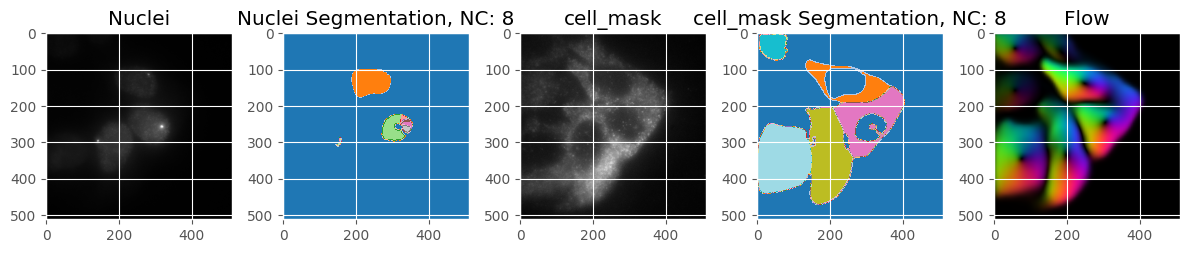

In [4]:
pipeline.run_up_to('TrackPy_SpotDetection')

In [6]:
pipeline.run_single_step(TrackPy_SpotDetection(), {'spot_yx_px': 5,
                                                'spot_z_px': 3,
                                                'trackpy_seperation_yx_px': 1,
                                                'trackpy_minmass': 6500,
                                                'trackpy_percentile': 90,
                                                # 'trackpy_maxsize': 1.4,
                                                'trackpy_use_pca': True,
                                                'cluster_radius': 1000,})

Overwriting spot_yx_px in dict
Overwriting spot_z_px in dict
Overwriting trackpy_seperation_yx_px in dict
Overwriting trackpy_minmass in dict
Overwriting trackpy_percentile in dict
Overwriting trackpy_maxsize in dict
Overwriting trackpy_use_pca in dict
Overwriting cluster_radius in dict

 ###################### 
        IMAGE : 0
 ###################### 
    Image Name :   JackRealImages_nzstack-13_zstep-0_tp_0_fov_0.tif


AssertionError: <code object refine_com_arr at 0x000002A5824B47D0, file "c:\Users\Jack\Documents\GitHub\FISH_Processing\.venv\Lib\site-packages\trackpy\refine\center_of_mass.py", line 99> != <code object _numba_refine_3D at 0x000002A5252F4C00, file "c:\Users\Jack\Documents\GitHub\FISH_Processing\.venv\Lib\site-packages\trackpy\refine\center_of_mass.py", line 557>

In [ ]:
pipeline.run_single_step(TrackPyAnlaysis())

In [7]:
# pickel load in the pipeline
pipeline = pickle.load(open('pipeline.pkl', 'rb'))

In [8]:
pipeline.run_single_step(TrackPy_SpotDetection(), {'cytoChannel': [0],
                                                'nucChannel': [2],
                                                'FISHChannel': [1],
                                                'spot_yx_px': 5,
                                                'spot_z_px': 3,
                                                'trackpy_seperation_yx_px': 1,
                                                'trackpy_minmass': 6500,
                                                'trackpy_percentile': 90,
                                                'trackpy_maxsize': 1.4,
                                                'trackpy_use_pca': True,
                                                'cluster_radius': 1000,})
                         
                         
                         
                                                #     {'spot_yx': 300,
                                                #    'spot_z':390, 
                                                #    'bigfish_alpha': 0.99, 
                                                #    'bigfish_beta': 3, 
                                                #    'bigfish_gamma': 7, 
                                                #    'cluster_radius': 1000,
                                                #    'snr_ratio': 0.7})

In [ ]:
from scipy.fft import fftn, fftshift

rna = pipelineData.list_images[0][:, :, :, 0]
rna = np.max(rna, axis=0)
ft = fftshift(np.abs(fftn(rna)))
plt.imshow(ft[440:460, 275:325])
plt.show()
